In [1]:
import sys
import os
import json
import fitz  # PyMuPDF
from pathlib import Path
from typing import TypedDict, Optional, Dict, List, Any
from IPython.display import Image, display
from dotenv import load_dotenv

# 1. Project Root & Env Setup
root = Path().resolve().parent
if str(root) not in sys.path:
    sys.path.append(str(root))

load_dotenv() # Loads TAVILY_API_KEY, GOOGLE_API_KEY, NEO4J credentials

from config import settings
from langchain_google_genai import ChatGoogleGenerativeAI, GoogleGenerativeAIEmbeddings
from langchain_community.graphs import Neo4jGraph
from langchain_community.vectorstores import Neo4jVector
from tavily import TavilyClient

# 2. Initialize Models & Tools
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)
tavily_client = TavilyClient(api_key=os.getenv("TAVILY_API_KEY"))

class FixedGoogleEmbeddings(GoogleGenerativeAIEmbeddings):
    def embed_query(self, text: str):
        return super().embed_documents([text])[0]

embeddings = FixedGoogleEmbeddings(model="models/gemini-embedding-001", output_dimensionality=768)

graph_db = Neo4jGraph(url=settings.NEO4J_URI, username=settings.NEO4J_USERNAME, password=settings.NEO4J_PASSWORD)

# 3. Built-in Retrievers
vector_retriever = Neo4jVector.from_existing_index(
    embeddings, url=settings.NEO4J_URI, username=settings.NEO4J_USERNAME, 
    password=settings.NEO4J_PASSWORD, index_name="occupation_embeddings", text_node_property="description"
)

def simple_vector_search(query: str):
    res = vector_retriever.similarity_search(query, k=1)
    return res[0].metadata if res else None

def vector_cypher_retriever(occupation_code: str):
    query = """
    MATCH (o:Occupation {code: $code})
    OPTIONAL MATCH (o)-[r:REQUIRES]->(s:Skill)
    OPTIONAL MATCH (o)-[:PERFORMS]->(t:Task)
    RETURN o.title as title, 
           collect(distinct {name: s.name, level: r.level})[0..10] as skills,
           collect(distinct t.statement)[0..5] as tasks
    """
    res = graph_db.query(query, {"code": occupation_code})
    return res[0] if res else None

print("✅ Phase 1: Models, Graph, & External Tools Connected!")

C:\Users\ASUS\AppData\Local\Temp\ipykernel_11336\2697303109.py:33: LangChainDeprecationWarning: The class `Neo4jGraph` was deprecated in LangChain 0.3.8 and will be removed in 1.0. An updated version of the class exists in the `langchain-neo4j package and should be used instead. To use it run `pip install -U `langchain-neo4j` and import as `from `langchain_neo4j import Neo4jGraph``.
  graph_db = Neo4jGraph(url=settings.NEO4J_URI, username=settings.NEO4J_USERNAME, password=settings.NEO4J_PASSWORD)


✅ Phase 1: Models, Graph, & External Tools Connected!


In [2]:
class TalentAngelState(TypedDict):
    user_query: str

    # Input Processing
    resume_path: Optional[str]
    resume_text: Optional[str]
    resume_skills: Optional[List[str]]

    # Core Fields
    current_role: Optional[str]
    target_role: Optional[str]
    intent: Optional[str]
    needs_clarification: bool

    # Retrieval Data
    locator_data: Optional[Dict]
    target_data: Optional[Dict]
    connector_data: Optional[Dict]

    # PARALLEL EXECUTION BUCKETS
    graph_gap_data: Optional[Dict]       
    market_research_data: Optional[Dict] 

    # Output & Routing
    final_response: Optional[str]
    critic_feedback: Optional[str]
    next_action: str
    supervisor_routes: Optional[List[str]]  # The Brain's decisions live here!

In [3]:
def parser_node(state: TalentAngelState):
    print("📄 Parser: Processing User Input & Resume...")
    pdf_path = state.get("resume_path")
    if pdf_path and os.path.exists(pdf_path):
        doc = fitz.open(pdf_path)
        raw_text = "\n".join([page.get_text() for page in doc])
        return {"resume_text": raw_text}
    return {"resume_text": None}

def role_extractor_node(state: TalentAngelState):
    print("🧠 Role Extractor: Understanding user intent...")
    query = state["user_query"]
    resume = state.get("resume_text") or ""

    EXTRACTION_PROMPT = """
    You are an information extraction system.
    Extract structured data from the user query and resume text (if provided).
    Return ONLY valid JSON.
    Schema:
    {
      "current_role": string or null,
      "target_role": string or null,
      "intent": "transition" | "role_info" | "off_topic",
      "needs_clarification": boolean,
      "resume_skills": list of top 5 skills (strings) or empty list
    }
    Rules:
    - If user wants to switch → intent = "transition"
    - If asking about a role → "role_info"
    - If current role missing in transition → needs_clarification = true
    """
    
    try:
        response = llm.invoke(EXTRACTION_PROMPT + f'\nQuery: "{query}"\nResume: {resume[:1500]}').content.strip()
    except Exception as e:
        print("LLM ERROR:", e)
        response = "{}"

    try:
        data = json.loads(response)
    except:
        try:
            fixed = response[response.index("{"):response.rindex("}")+1]
            data = json.loads(fixed)
        except:
            data = {}

    current_role = data.get("current_role")
    target_role = data.get("target_role")
    intent = data.get("intent", "transition")
    needs_clarification = data.get("needs_clarification", False)

    if isinstance(current_role, str): current_role = current_role.strip().lower()
    if isinstance(target_role, str): target_role = target_role.strip().lower()
    if intent == "transition" and not current_role: needs_clarification = True

    print(f"   -> current_role: {current_role} | target_role: {target_role} | intent: {intent}")

    return {
        "current_role": current_role,
        "target_role": target_role,
        "intent": intent,
        "needs_clarification": needs_clarification,
        "resume_skills": data.get("resume_skills", []),
        "next_action": "gatekeeper"
    }

def gatekeeper_node(state: TalentAngelState):
    print("🛡️ Gatekeeper: Validating query...")
    if state["intent"] == "off_topic": return {"final_response": "I can only help with career-related queries.", "next_action": "end"}
    if state["needs_clarification"]: return {"final_response": "Please tell me your current profession so I can guide your transition.", "next_action": "end"}
    return {"next_action": "locator"}

def locator_node(state: TalentAngelState):
    print("📍 Locator: Finding current role...")
    role = state.get("current_role")
    if not role: return {"final_response": "Please tell me your current role.", "next_action": "end"}
    
    result = simple_vector_search(role)
    if not result: return {"final_response": f"I couldn't find '{role}' in O*NET.", "next_action": "end"}
    
    print(f"   -> Found: {result['title']}")
    return {"locator_data": result, "next_action": "connector"}

def connector_node(state: TalentAngelState):
    print("🔗 Connector: Fetching graph data...")
    code = state["locator_data"]["code"]
    data = vector_cypher_retriever(code)

    if not data: return {"connector_data": None, "next_action": "market_researcher"}

    skills = data.get("skills", [])
    clean_skills = [s for s in skills if s and s.get("name") is not None]
    data["skills"] = clean_skills

    return {"connector_data": data, "next_action": "supervisor"} # Route to The Brain

def supervisor_node(state: TalentAngelState):
    print("👔 SUPERVISOR (Orchestrator): Analyzing state to delegate tasks...")
    intent = state.get("intent")
    target_role = state.get("target_role")
    
    prompt = f"""
    You are the Orchestrator for an AI Career Agent.
    The user's intent is: '{intent}'.
    They are targeting the role: '{target_role}'.
    
    Decide which tools need to run based on the intent. 
    - If it's a full career "transition", we need BOTH the static graph data AND live market data. Return: ["pathfinder", "market_researcher"]
    - If it's just "role_info" (fact-finding), we ONLY need live market data. Return: ["market_researcher"]
    
    Return ONLY a valid JSON array of the tool names. Example: ["pathfinder", "market_researcher"]
    """
    
    try:
        res = llm.invoke(prompt).content.replace("```json", "").replace("```", "").strip()
        routes = json.loads(res)
        if not isinstance(routes, list): routes = ["pathfinder", "market_researcher"]
    except Exception as e:
        print(f"   -> Supervisor LLM Error: {e}. Defaulting to parallel execution.")
        routes = ["pathfinder", "market_researcher"]

    print(f"   -> Decision: Fanning out to {routes} 🚀")
    
    return {"supervisor_routes": routes}

def pathfinder_node(state: TalentAngelState):
    print("🛤️ Pathfinder [PARALLEL]: Calculating transition gap from Graph...")
    target_role = state.get("target_role")
    if not target_role: return {"graph_gap_data": None}

    target_job = simple_vector_search(target_role)
    if not target_job: return {"graph_gap_data": None}

    gap_query = """
    MATCH (target:Occupation {code: $target_code})-[r_target:REQUIRES]->(s:Skill)
    OPTIONAL MATCH (current:Occupation {code: $current_code})-[r_current:REQUIRES]->(s)
    WITH s, COALESCE(r_target.level, 0) AS t, COALESCE(r_current.level, 0) AS c
    WHERE t > c AND s.name IS NOT NULL
    RETURN s.name AS skill, (t - c) AS gap
    ORDER BY gap DESC LIMIT 5
    """
    gap_data = graph_db.query(gap_query, {"current_code": state["locator_data"]["code"], "target_code": target_job["code"]})
    clean_gaps = [g for g in gap_data if g.get("skill") is not None]

    if not clean_gaps:
        connector_skills = state.get("connector_data", {}).get("skills", [])
        clean_gaps = [{"skill": s["name"], "gap": 1.0} for s in connector_skills[:5] if s.get("name")]

    return {"graph_gap_data": {"target_role": target_job["title"], "gaps": clean_gaps}, "target_data": target_job}

def market_researcher_node(state: TalentAngelState):
    print("📈 Researcher [PARALLEL]: Getting live Tavily market insights...")
    job = state.get("target_data", {}).get("title") or state["locator_data"]["title"]

    try:
        search_result = tavily_client.search(f"Average salary and market demand for {job} in 2026", search_depth="basic")
        insights = "\n".join([r['content'] for r in search_result['results']])
    except Exception as e:
        print(f"   -> Tavily Error: {e}")
        insights = llm.invoke(f"Give 2 factual sentences about demand and salary for {job}.").content

    return {"market_research_data": {"insights": insights[:500]}}

def data_aggregator_node(state: TalentAngelState):
    print("🔄 Aggregator: Syncing Fan-Out Data...")
    return {"next_action": "consultor"}

def consultor_node(state: TalentAngelState):
    print("👼 Consultor: Generating roadmap...")
    current_role = state["locator_data"]["title"]
    target_role = state.get("graph_gap_data", {}).get("target_role", current_role)
    gaps = state.get("graph_gap_data", {}).get("gaps", [])
    gap_text = ", ".join([f"{g['skill']} (+{round(g['gap'],1)})" for g in gaps]) if gaps else "No major gaps"
    market = state.get("market_research_data", {}).get("insights", "Market data unavailable")

    context = f"""
    Current Role: {current_role}
    Target Role: {target_role}
    Skill Gaps: {gap_text}
    Market Insights: {market}
    """
    prompt = f"You are a career strategist.\nContext:\n{context}\nWrite a 5-6 sentence career transition plan using the skill gaps and live market data."
    if state.get("critic_feedback"): prompt += f"\nFix this issue: {state['critic_feedback']}"

    return {"final_response": llm.invoke(prompt).content, "next_action": "critic"}

def critic_node(state: TalentAngelState):
    print("🧐 Critic: Reviewing response...")
    draft = state["final_response"]
    prompt = f"Evaluate this response:\n{draft}\nRules: Must mention correct roles, not hallucinate, 5-6 sentences.\nOutput:\nSCORE: X\nFEEDBACK: text"
    
    evaluation = llm.invoke(prompt).content
    try:
        score = int(evaluation.split("SCORE:")[1].split("\n")[0])
        feedback = evaluation.split("FEEDBACK:")[1]
    except:
        score, feedback = 10, "APPROVED"

    if score < 8: return {"critic_feedback": feedback, "next_action": "consultor"}
    return {"next_action": "end"}

In [6]:
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver

workflow = StateGraph(TalentAngelState)

# 1. Add all nodes
workflow.add_node("parser", parser_node)
workflow.add_node("role_extractor", role_extractor_node)
workflow.add_node("gatekeeper", gatekeeper_node)
workflow.add_node("locator", locator_node)
workflow.add_node("connector", connector_node)
workflow.add_node("supervisor", supervisor_node)  # The Brain
workflow.add_node("pathfinder", pathfinder_node)
workflow.add_node("market_researcher", market_researcher_node)
workflow.add_node("data_aggregator", data_aggregator_node)
workflow.add_node("consultor", consultor_node)
workflow.add_node("critic", critic_node)

workflow.set_entry_point("parser")

def route_standard(state):
    return state["next_action"]

# 2. Sequential Pathway
workflow.add_edge("parser", "role_extractor")
workflow.add_edge("role_extractor", "gatekeeper")
workflow.add_conditional_edges("gatekeeper", route_standard, {"locator": "locator", "end": END})
workflow.add_edge("locator", "connector")
workflow.add_edge("connector", "supervisor")

# 3. 🔀 THE FAN-OUT (Supervisor reads the LLM's dynamic decision)
def route_from_supervisor(state):
    return state.get("supervisor_routes", ["pathfinder", "market_researcher"])

workflow.add_conditional_edges("supervisor", route_from_supervisor, ["pathfinder", "market_researcher"])

# 4. 🔄 THE FAN-IN
workflow.add_edge("pathfinder", "data_aggregator")
workflow.add_edge("market_researcher", "data_aggregator")
workflow.add_edge("data_aggregator", "consultor")

# 5. Synthesis & Loop
workflow.add_edge("consultor", "critic")
workflow.add_conditional_edges("critic", route_standard, {"consultor": "consultor", "end": END})

memory = MemorySaver()
talent_app = workflow.compile(checkpointer=memory)
print("✅ V2 Enterprise Graph Compiled Successfully!")

✅ V2 Enterprise Graph Compiled Successfully!


🎨 Generating V2 Architecture Map...


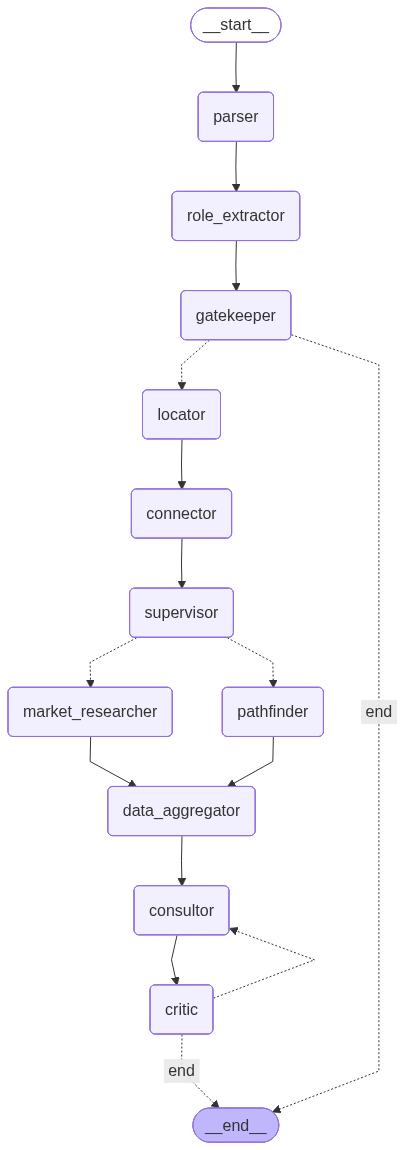


🚀 LAUNCHING V2 FULL PIPELINE TEST


In [7]:
print("🎨 Generating V2 Architecture Map...")
try:
    display(Image(talent_app.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Could not fetch image, displaying ASCII...")
    print(talent_app.get_graph().draw_ascii())

print("\n" + "="*50)
print("🚀 LAUNCHING V2 FULL PIPELINE TEST")
print("="*50)



In [8]:
def run_orchestrator(query, resume_path=None):
    config = {"configurable": {"thread_id": "v2_master_session"}}
    return talent_app.invoke({
        "user_query": query, 
        "resume_path": resume_path
    }, config=config)

# Execute the agent
final_state = run_orchestrator("I am a data scientist and I want to transition to a technical writer")

print("\n" + "="*50)
print("👼 FINAL ANGEL ROADMAP:")
print("="*50)
print(final_state["final_response"])

📄 Parser: Processing User Input & Resume...
🧠 Role Extractor: Understanding user intent...
   -> current_role: data scientist | target_role: technical writer | intent: transition
🛡️ Gatekeeper: Validating query...
📍 Locator: Finding current role...
   -> Found: Data Scientists
🔗 Connector: Fetching graph data...
👔 SUPERVISOR (Orchestrator): Analyzing state to delegate tasks...
   -> Decision: Fanning out to ['pathfinder', 'market_researcher'] 🚀
📈 Researcher [PARALLEL]: Getting live Tavily market insights...
🛤️ Pathfinder [PARALLEL]: Calculating transition gap from Graph...
🔄 Aggregator: Syncing Fan-Out Data...
👼 Consultor: Generating roadmap...
🧐 Critic: Reviewing response...

👼 FINAL ANGEL ROADMAP:
Transitioning from a Data Scientist to a Technical Writer requires a strategic focus on bridging significant communication skill gaps. Prioritize intensive development in writing, reading comprehension, and speaking, perhaps through specialized courses and practical application. Leverage yo

In [21]:
import fitz  # PyMuPDF

# Create a blank PDF
doc = fitz.open()
page = doc.new_page()

# Add fake resume text tailored for our test
resume_content = """
VISHWAJIT
Current Role: Chief Executive

Experience:
- Led corporate strategy and managed global operations.
- Spearheaded major enterprise negotiations.

Skills:
Leadership, Public Speaking, Corporate Strategy, Budgeting, Curriculum Design
"""

# Insert text into the PDF and save it
page.insert_text((50, 50), resume_content, fontsize=12)
doc.save("dummy_resume.pdf")
print("📄 dummy_resume.pdf created successfully!")

📄 dummy_resume.pdf created successfully!


In [23]:
print("\n" + "="*50)
print("🚀 LAUNCHING V2 DUMMY RESUME TEST")
print("="*50)

# Execute the agent, passing the dummy PDF
final_state = run_orchestrator(
    query="I want to transition to a Teacher. What are my gaps?", 
    resume_path="dummy_resume.pdf" 
)

print("\n" + "="*50)
print("👼 FINAL ANGEL ROADMAP:")
print("="*50)
print(final_state["final_response"])


🚀 LAUNCHING V2 DUMMY RESUME TEST
📄 Parser: Processing User Input & Resume...
🧠 Role Extractor: Understanding user intent...
   -> current_role: chief executive | target_role: teacher | intent: transition
🛡️ Gatekeeper: Validating query...
📍 Locator: Finding current role...
   -> Found: Chief Executives
🔗 Connector: Fetching graph data...
👔 SUPERVISOR (Orchestrator): Analyzing state to delegate tasks...
   -> Decision: Fanning out to ['pathfinder', 'market_researcher'] 🚀
🛤️ Pathfinder [PARALLEL]: Calculating transition gap from Graph...
📈 Researcher [PARALLEL]: Getting live Tavily market insights...
🔄 Aggregator: Syncing Fan-Out Data...
👼 Consultor: Generating roadmap...
🧐 Critic: Reviewing response...
👼 Consultor: Generating roadmap...
🧐 Critic: Reviewing response...

👼 FINAL ANGEL ROADMAP:
Transitioning from a Chief Executive to a Secondary School Teacher requires a strategic pivot focusing on pedagogical development. Prioritize closing skill gaps in Science, Learning Strategies, and